# 01 - Exploratory Data Analysis (EDA)
## Home Credit Default Risk

**Objetivo:** Entender a estrutura dos dados, distribuições, valores nulos e correlações antes de construir as features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR = '../data'
print('Setup completo!')

Setup completo!


## 1. Carregamento dos Dados

In [2]:
train = pd.read_csv(f'{DATA_DIR}/application_train.csv')
test  = pd.read_csv(f'{DATA_DIR}/application_test.csv')
print(f'Train: {train.shape}  |  Test: {test.shape}')
train.head(3)

Train: (307511, 122)  |  Test: (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,...,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,...,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,...,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-815.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## 2. Target Distribution (Balanceamento de Classes)

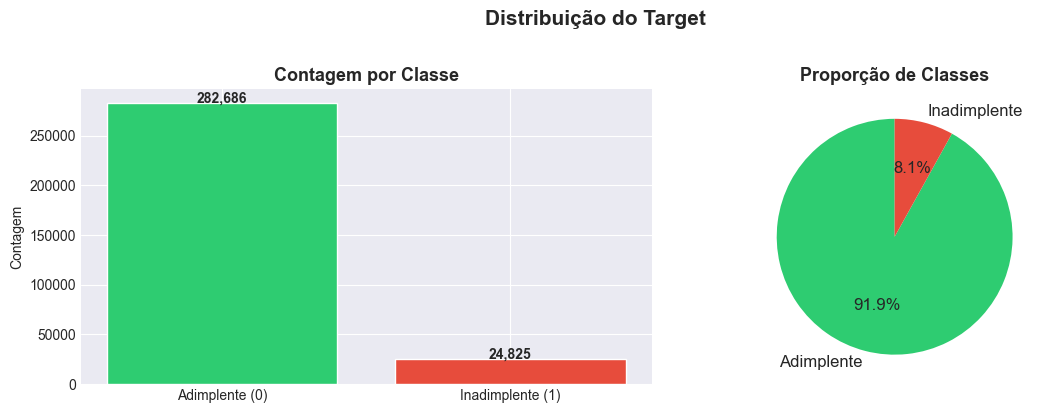


Taxa de Inadimplência: 8.07%


In [3]:
target_counts = train['TARGET'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Contagem absoluta
axes[0].bar(['Adimplente (0)', 'Inadimplente (1)'], target_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_title('Contagem por Classe', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Contagem')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Percentual
axes[1].pie(target_counts.values, labels=['Adimplente', 'Inadimplente'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporção de Classes', fontsize=13, fontweight='bold')

plt.suptitle('Distribuição do Target', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/eda_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'\nTaxa de Inadimplência: {target_counts[1]/len(train)*100:.2f}%')

## 3. Missing Values — application_train.csv

Colunas com dados nulos: 67 / 122


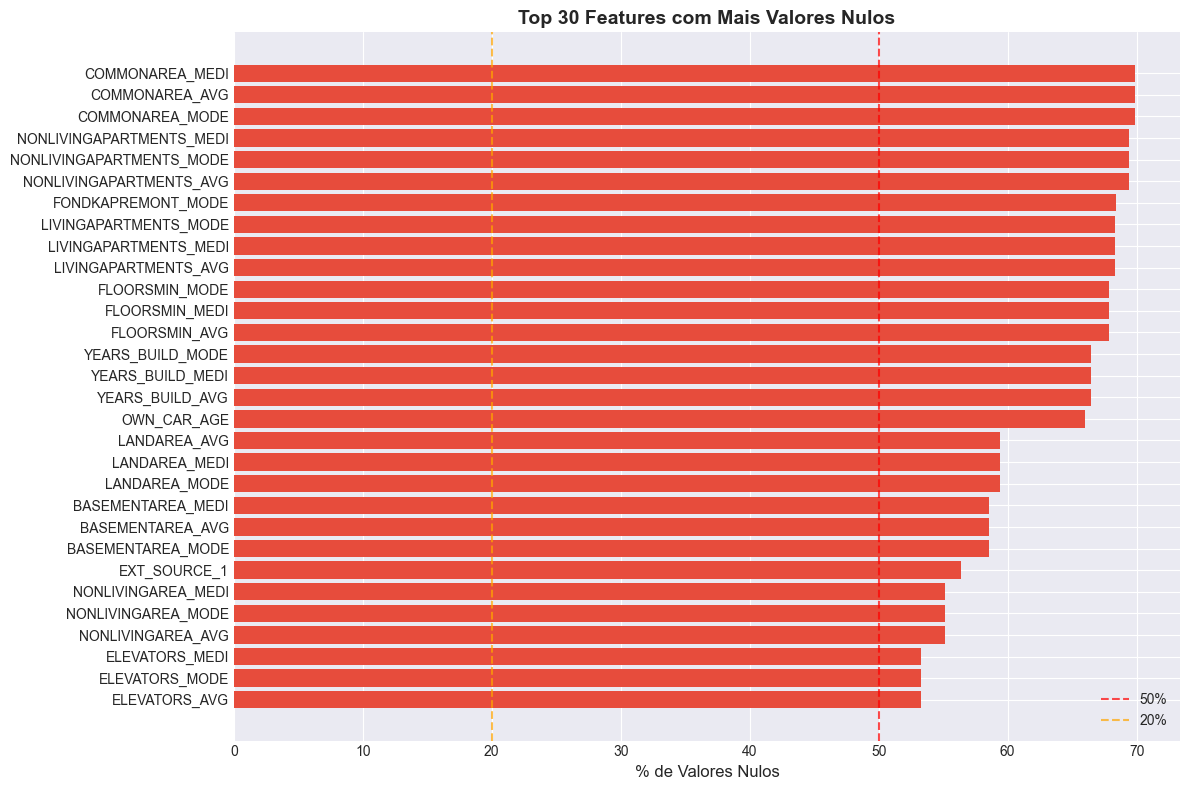

,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.8700
COMMONAREA_AVG,214865,69.8700
COMMONAREA_MODE,214865,69.8700
NONLIVINGAPARTMENTS_MEDI,213514,69.4300
NONLIVINGAPARTMENTS_MODE,213514,69.4300
NONLIVINGAPARTMENTS_AVG,213514,69.4300
FONDKAPREMONT_MODE,210295,68.3900
LIVINGAPARTMENTS_MODE,210199,68.3500
LIVINGAPARTMENTS_MEDI,210199,68.3500
LIVINGAPARTMENTS_AVG,210199,68.3500


In [4]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df.missing_count > 0].sort_values('missing_pct', ascending=False)

print(f'Colunas com dados nulos: {len(missing_df)} / {train.shape[1]}')

fig, ax = plt.subplots(figsize=(12, 8))
top30 = missing_df.head(30)
colors = ['#e74c3c' if p > 50 else '#f39c12' if p > 20 else '#3498db'
          for p in top30['missing_pct']]
bars = ax.barh(top30.index[::-1], top30['missing_pct'][::-1], color=colors[::-1])
ax.set_xlabel('% de Valores Nulos', fontsize=12)
ax.set_title('Top 30 Features com Mais Valores Nulos', fontsize=14, fontweight='bold')
ax.axvline(50, color='red', linestyle='--', alpha=0.7, label='50%')
ax.axvline(20, color='orange', linestyle='--', alpha=0.7, label='20%')
ax.legend()
plt.tight_layout()
plt.savefig('../data/eda_missing_values.png', dpi=120, bbox_inches='tight')
plt.show()

missing_df.head(20)

## 4. Features Numéricas — Distribuições Principais

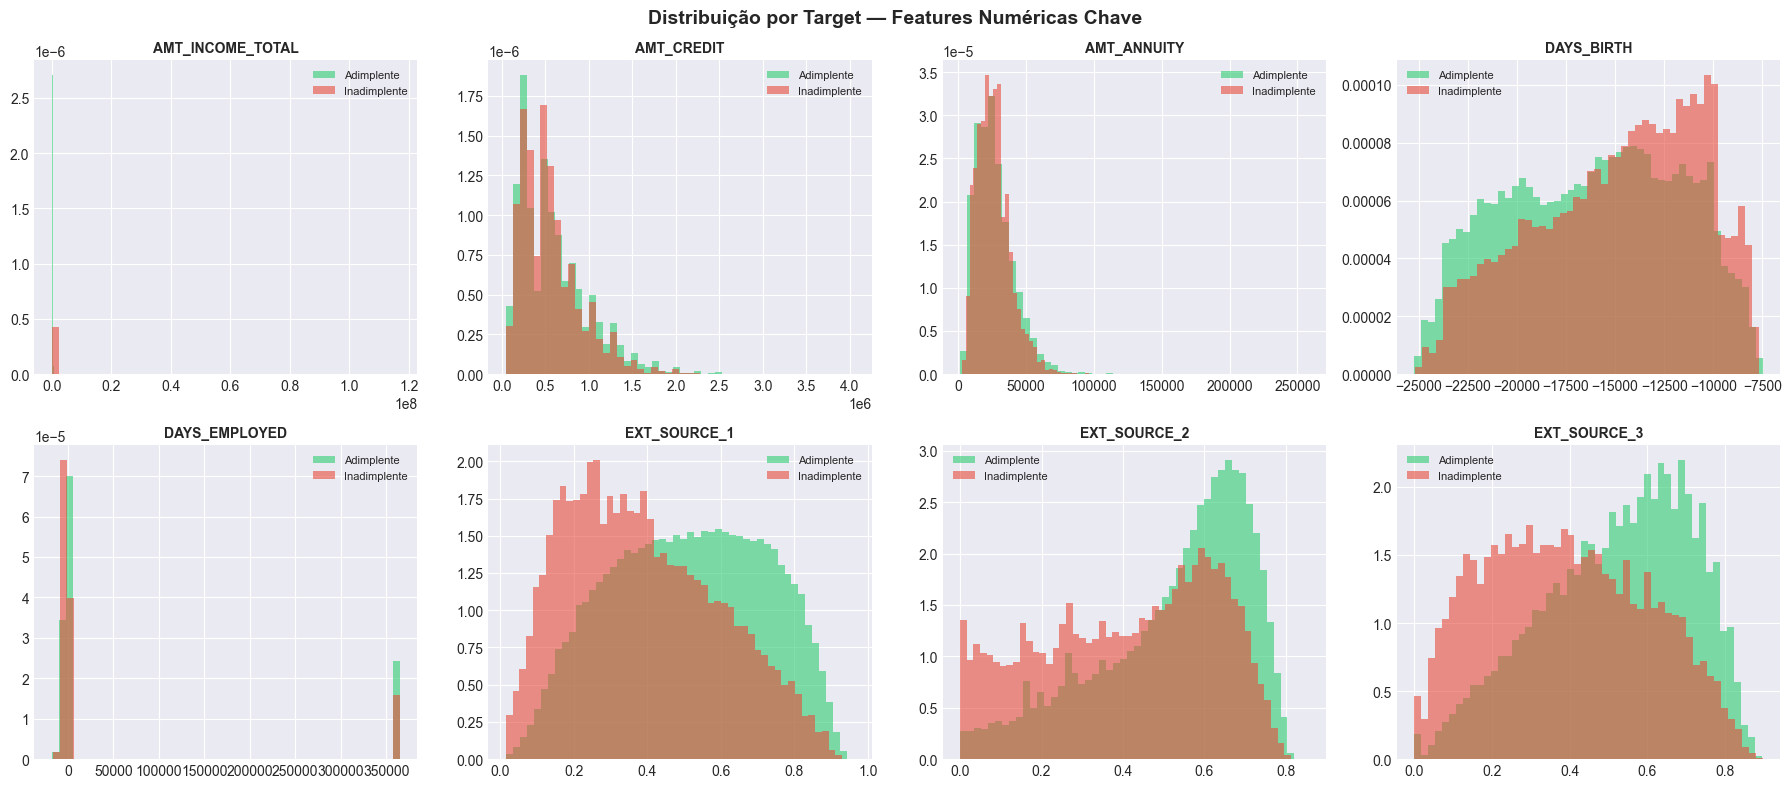

In [5]:
key_features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), key_features):
    data0 = train.loc[train['TARGET']==0, col].dropna()
    data1 = train.loc[train['TARGET']==1, col].dropna()
    ax.hist(data0, bins=50, alpha=0.6, color='#2ecc71', label='Adimplente', density=True)
    ax.hist(data1, bins=50, alpha=0.6, color='#e74c3c', label='Inadimplente', density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribuição por Target — Features Numéricas Chave', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_key_features.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Correlações com o Target

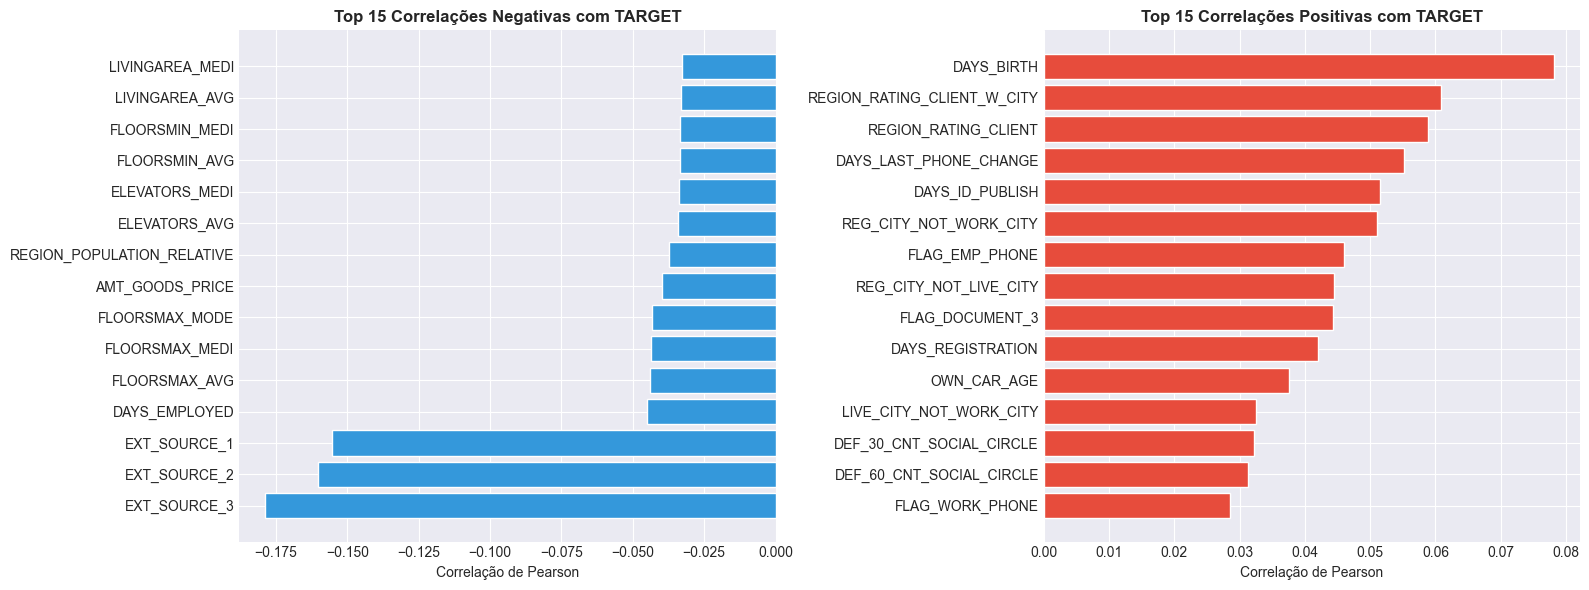

In [6]:
numeric_cols = train.select_dtypes('number').columns.drop('TARGET')
correlations = train[numeric_cols].corrwith(train['TARGET']).dropna().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlações mais negativas
top_neg = correlations.head(15)
axes[0].barh(top_neg.index, top_neg.values, color='#3498db', edgecolor='white')
axes[0].set_title('Top 15 Correlações Negativas com TARGET', fontweight='bold')
axes[0].set_xlabel('Correlação de Pearson')

# Correlações mais positivas
top_pos = correlations.tail(15)
axes[1].barh(top_pos.index, top_pos.values, color='#e74c3c', edgecolor='white')
axes[1].set_title('Top 15 Correlações Positivas com TARGET', fontweight='bold')
axes[1].set_xlabel('Correlação de Pearson')

plt.tight_layout()
plt.savefig('../data/eda_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Visão Geral das Tabelas Auxiliares

In [7]:
aux_tables = [
    'bureau.csv', 'bureau_balance.csv', 'previous_application.csv',
    'POS_CASH_balance.csv', 'installments_payments.csv', 'credit_card_balance.csv'
]

for table in aux_tables:
    path = f'{DATA_DIR}/{table}'
    if os.path.exists(path):
        df = pd.read_csv(path, nrows=5)
        full = pd.read_csv(path)
        print(f'\n=== {table} ===')
        print(f'Shape: {full.shape}  |  ID Único: {full["SK_ID_CURR"].nunique() if "SK_ID_CURR" in full.columns else "N/A"} clientes')
        print(df.dtypes.to_string())
        del full
    else:
        print(f'⚠️  {table} - aguardando download...')


=== bureau.csv ===
Shape: (1716428, 17)  |  ID Único: 305811 clientes
SK_ID_CURR                  int64
SK_ID_BUREAU                int64
CREDIT_ACTIVE              object
CREDIT_CURRENCY            object
DAYS_CREDIT                 int64
CREDIT_DAY_OVERDUE          int64
DAYS_CREDIT_ENDDATE       float64
DAYS_ENDDATE_FACT         float64
AMT_CREDIT_MAX_OVERDUE    float64
CNT_CREDIT_PROLONG          int64
AMT_CREDIT_SUM            float64
AMT_CREDIT_SUM_DEBT       float64
AMT_CREDIT_SUM_LIMIT      float64
AMT_CREDIT_SUM_OVERDUE    float64
CREDIT_TYPE                object
DAYS_CREDIT_UPDATE          int64
AMT_ANNUITY               float64

=== bureau_balance.csv ===
Shape: (27299925, 3)  |  ID Único: N/A clientes
SK_ID_BUREAU       int64
MONTHS_BALANCE     int64
STATUS            object

=== previous_application.csv ===
Shape: (1670214, 37)  |  ID Único: 338857 clientes
SK_ID_PREV                       int64
SK_ID_CURR                       int64
NAME_CONTRACT_TYPE              objec